# Univariate and Multivariate Analysis
**Data Science Course — Exploratory Data Analysis with Python Submission Assignment**

Using the **diamonds** seaborn dataset to perform:
- **Univariate Analysis** — examining one variable at a time (`price`)
- **Multivariate Analysis** — examining relationships between multiple variables (`price` vs `carat`, `price` by `cut`)

## Step 1 — Import Seaborn and Load the Diamonds Dataset
As instructed, we import seaborn and load the built-in diamonds dataset.

In [1]:
import seaborn as sns

diamonds = sns.load_dataset('diamonds')

## Step 2 — Import Relevant Libraries
We import additional libraries needed for statistical analysis and visualization:
- **numpy** — numerical operations and descriptive statistics
- **matplotlib** — low-level plotting control
- **pandas** — DataFrame inspection

In [2]:
import numpy as np                   # numerical computing and statistics
import matplotlib.pyplot as plt      # plot rendering and layout control
import pandas as pd                  # DataFrame utilities

# display all matplotlib charts inline inside the notebook
%matplotlib inline

## Step 3 — Initial Dataset Exploration
Before analysis we take a quick look at the dataset's structure:
shape, column names, data types, and the first few rows.

In [3]:
# shape tells us how many rows and columns are in the dataset
print('Dataset shape:', diamonds.shape)

# preview the first 5 rows to see column names and sample values
diamonds.head()

Dataset shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
# statistical summary of all numerical columns:
# count, mean, std, min, 25th/50th/75th percentile, max
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


---
## Step 4 — Univariate Analysis: `price`

**Univariate analysis** examines a single variable in isolation to understand its distribution,
central tendency, spread, and any outliers.

**Chosen variable: `price`** (the retail price of the diamond in US dollars)

We chose `price` because it is the most practically important variable in the dataset —
understanding how prices are distributed reveals whether the market is concentrated
at low values, spread evenly, or skewed by a few high-value gems.

In [5]:
# --- DESCRIPTIVE STATISTICS FOR price ---
# numpy gives us precise control over which statistics to compute
print('=== Univariate Analysis: price ===')
print(f'Count  : {len(diamonds["price"]):,}')
print(f'Mean   : ${np.mean(diamonds["price"]):,.2f}')
print(f'Median : ${np.median(diamonds["price"]):,.2f}')
print(f'Std Dev: ${np.std(diamonds["price"]):,.2f}')
print(f'Min    : ${np.min(diamonds["price"]):,.2f}')
print(f'Max    : ${np.max(diamonds["price"]):,.2f}')

=== Univariate Analysis: price ===
Count  : 53,940
Mean   : $3,932.80
Median : $2,401.00
Std Dev: $3,989.40
Min    : $326.00
Max    : $18,823.00


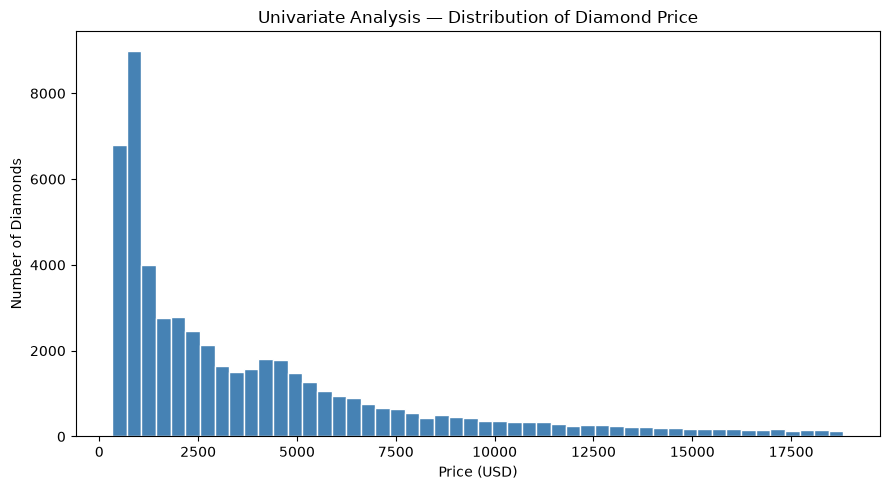

In [6]:
# --- HISTOGRAM of price ---
# a histogram shows how values are distributed across bins (ranges)
# right-skew (long tail to the right) indicates most diamonds are lower-priced
# but a small number have very high prices
plt.figure(figsize=(9, 5))
plt.hist(diamonds['price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Univariate Analysis — Distribution of Diamond Price')
plt.xlabel('Price (USD)')
plt.ylabel('Number of Diamonds')
plt.tight_layout()
plt.show()

/var/folders/zf/rgqg6trn25597cd583c21knw0000gn/T/ipykernel_21955/1602565344.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(diamonds['price'], vert=True, patch_artist=True,


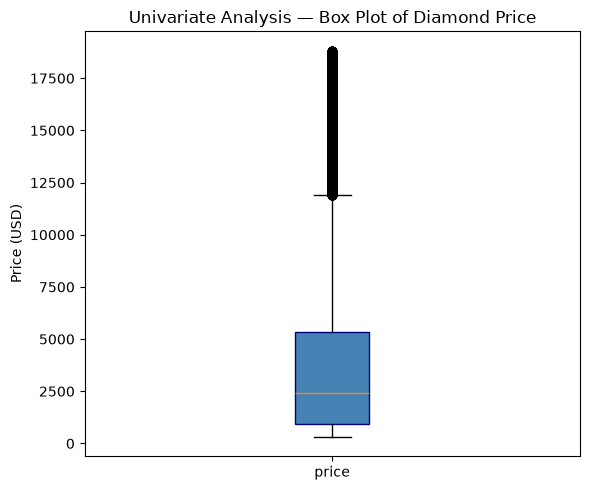

In [7]:
# --- BOX PLOT of price ---
# a box plot shows the median (orange line), interquartile range (box),
# and outliers (dots beyond the whiskers)
# this confirms the right-skew seen in the histogram
plt.figure(figsize=(6, 5))
plt.boxplot(diamonds['price'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='navy'))
plt.title('Univariate Analysis — Box Plot of Diamond Price')
plt.ylabel('Price (USD)')
plt.xticks([1], ['price'])
plt.tight_layout()
plt.show()

### Univariate Findings
- The price distribution is **right-skewed**: most diamonds sell for under \$2,500, but a long tail extends to \$18,823.
- The **mean** (\$3,932) is significantly higher than the **median** (\$2,401), confirming the skew.
- The box plot shows many high-price outliers above the upper whisker.

---
## Step 5 — Multivariate Analysis: `price` vs `carat` and `price` by `cut`

**Multivariate analysis** examines relationships between two or more variables to identify
patterns, correlations, and group differences.

**Chosen variables:**
- `price` vs `carat` — a scatter plot to see how diamond weight relates to price
- `price` by `cut` — a grouped box plot to compare price distributions across cut quality grades
- Correlation heatmap — to see how all numerical variables relate to each other

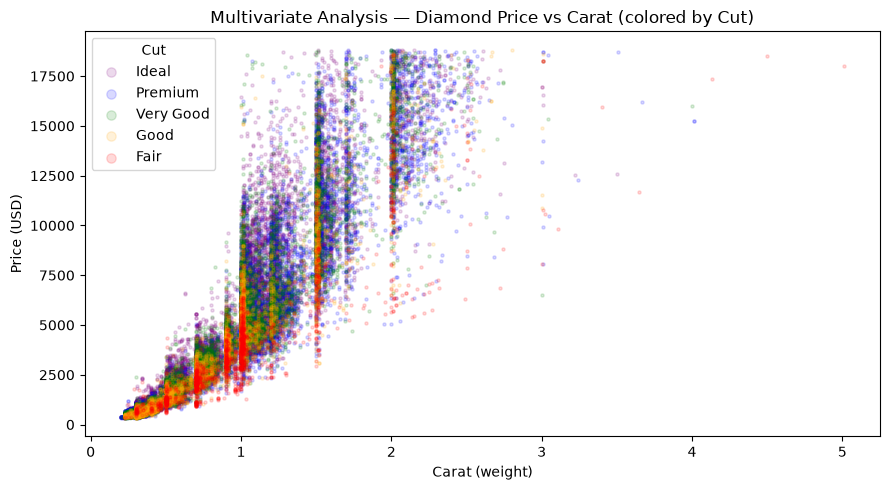

In [8]:
# --- SCATTER PLOT: price vs carat ---
# each dot is one diamond; we can see whether heavier diamonds cost more
# color-coded by 'cut' quality so we can spot three variables at once
plt.figure(figsize=(9, 5))

# define a color for each cut grade
cut_colors = {'Fair': 'red', 'Good': 'orange', 'Very Good': 'green',
              'Premium': 'blue', 'Ideal': 'purple'}

for cut_grade, group in diamonds.groupby('cut', observed=True):
    plt.scatter(group['carat'], group['price'],
                label=cut_grade, color=cut_colors[cut_grade],
                alpha=0.15, s=5)

plt.title('Multivariate Analysis — Diamond Price vs Carat (colored by Cut)')
plt.xlabel('Carat (weight)')
plt.ylabel('Price (USD)')
plt.legend(title='Cut', markerscale=3)
plt.tight_layout()
plt.show()

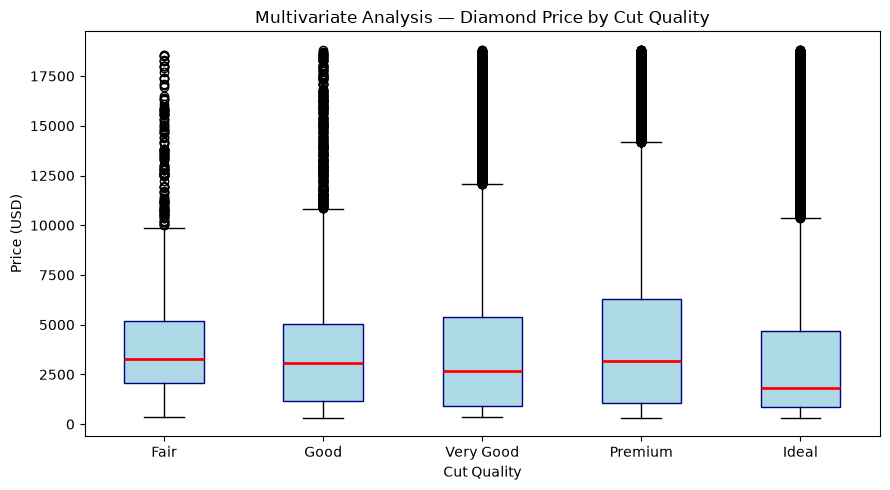

In [9]:
# --- GROUPED BOX PLOT: price by cut ---
# compares the price distribution across each cut quality grade
# lets us answer: does a better cut always mean a higher price?
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
price_by_cut = [diamonds[diamonds['cut'] == c]['price'].values for c in cut_order]

plt.figure(figsize=(9, 5))
plt.boxplot(price_by_cut, tick_labels=cut_order, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Multivariate Analysis — Diamond Price by Cut Quality')
plt.xlabel('Cut Quality')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

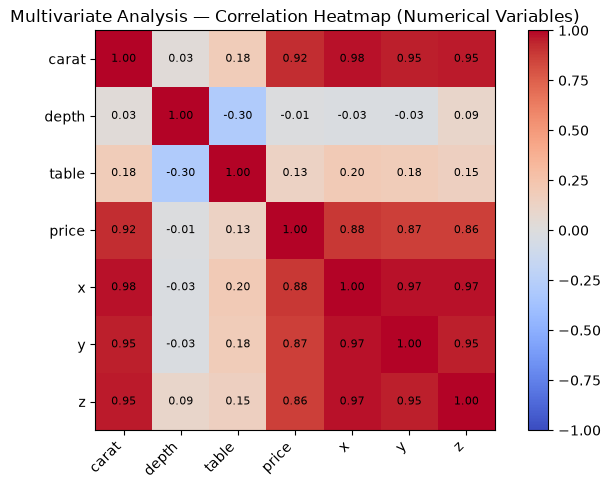

In [10]:
# --- CORRELATION HEATMAP ---
# a correlation matrix shows how strongly every pair of numerical variables
# is related; values range from -1 (perfect inverse) to +1 (perfect direct)
# this is a key multivariate tool for identifying which features drive price

# select only numerical columns for correlation
numeric_cols = diamonds.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()

# plot the heatmap using matplotlib
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax)

# label the axes with column names
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)

# annotate each cell with its correlation value
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=8, color='black')

ax.set_title('Multivariate Analysis — Correlation Heatmap (Numerical Variables)')
plt.tight_layout()
plt.show()

### Multivariate Findings
- **Price vs Carat (scatter)**: There is a strong positive relationship — heavier diamonds cost more.
  The spread widens at higher carat values, showing that cut and clarity also influence price.
- **Price by Cut (box plot)**: Surprisingly, `Ideal` cut diamonds do **not** have the highest median price.
  `Fair` and `Premium` cuts show higher medians, likely because lower-quality cuts are often applied
  to larger (heavier) stones, which drives the price up regardless of cut grade.
- **Correlation heatmap**: `carat`, `x`, `y`, and `z` (diamond dimensions) all have a
  **strong positive correlation with price** (≥ 0.86), confirming that diamond size is
  the dominant factor in pricing.